In [61]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [62]:
tex_fonts = {
    
    # Use LaTeX to write all text
   "text.usetex": True,
   "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
   "axes.labelsize": 14,
   "font.size": 14,

   "legend.fontsize": 12,
   "xtick.labelsize": 12,
   "ytick.labelsize": 12
}

In [63]:
plt.rcParams.update(tex_fonts) # use latex fonts

In [64]:
out = Path("out")

fig_dir = Path("fig")
fig_dir.mkdir(exist_ok=True)

In [65]:
ckpt = pickle.load(open(out / "mc_full_and_reduced_2.p", "rb"))
ckpt_red = pickle.load(open(out / "mc_full_and_reduced_only_reduced.p", "rb"))
sequence_lens = ckpt["train_lens"]

In [66]:
# max_rmse = 2.0

# perf_full = np.nan_to_num(ckpt["rmse_full"], nan=max_rmse, posinf=max_rmse)
# perf_full[perf_full > max_rmse] = max_rmse

# perf_red = np.nan_to_num(ckpt_red["rmse_red"], nan=max_rmse, posinf=max_rmse)
# perf_red[perf_red > max_rmse] = max_rmse

# gap = perf_full - perf_red

In [67]:
perf_full = np.nan_to_num(ckpt["fit_full"], nan=0.0, neginf=0.0)
perf_full[perf_full < 0] = 0.0

perf_red = np.nan_to_num(ckpt_red["fit_red"], nan=0.0, neginf=0.0)
perf_red[perf_red < 0] = 0.0

gap = perf_full - perf_red

In [68]:
perf_red[1].shape

(2000,)

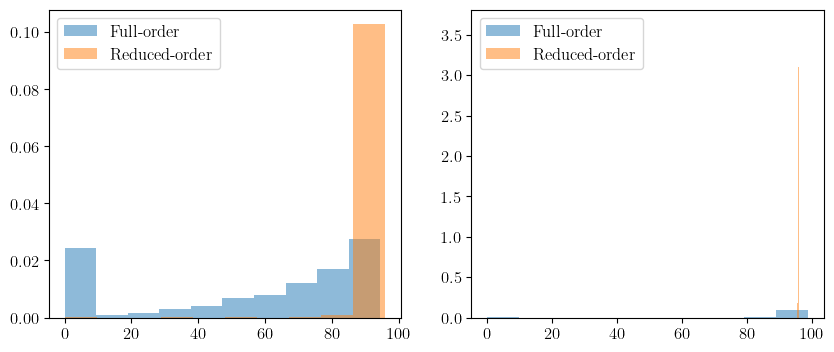

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(perf_full[0], alpha=0.5, label="Full-order", color="C0", density=True)#, bins=30)
ax[0].hist(perf_red[0], alpha=0.5, label="Reduced-order", color="C1", density=True)#, bins=100)
ax[0].legend()
ax[1].hist(perf_full[1], alpha=0.5, label="Full-order", color="C0", density=True)#, bins=30)
ax[1].hist(perf_red[1], alpha=0.5, label="Reduced-order", color="C1", density=True)#, bins=100)
ax[1].legend();

In [70]:
perf_red.shape

(2, 2000)

In [71]:
val_num = 1900
val_fit_full = perf_full[:, :val_num]
val_fit_red = perf_red[:, :val_num]
val_gap = gap[:, :val_num]

test_fit_full = perf_full[:, val_num:-1]
test_fit_red = perf_red[:, val_num:-1]
test_gap = gap[:, val_num:-1]

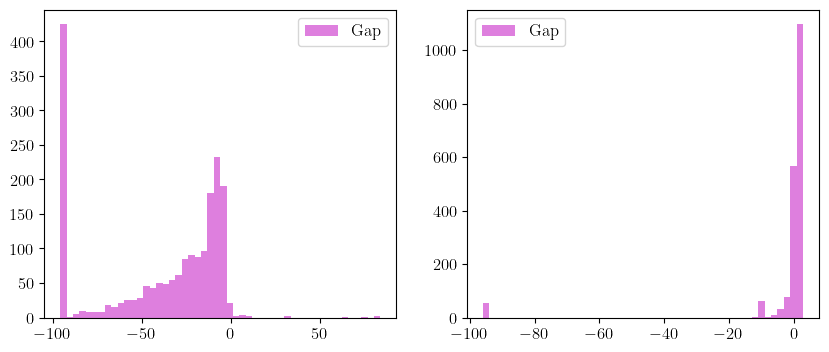

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(val_gap[0], bins=50, alpha=0.5, label="Gap", color="m");
ax[0].legend()
ax[1].hist(val_gap[1], bins=50, alpha=0.5, label="Gap", color="m");
ax[1].legend();

## Bound computations

In [73]:
m = val_gap.shape[1] # number of mc realizations
#m = 1800
delta = 0.01
alpha = 0.05
eps_m = np.sqrt(np.log(2/delta)/(2*m))
eps_m

np.float64(0.03734024697064055)

In [74]:
quant = 1 - alpha + eps_m; quant

np.float64(0.9873402469706405)

In [ ]:
#q_idx = int(quant * m); q_idx
q_idx = int(np.ceil(quant * m)); q_idx

1875

In [76]:
sorted_gap = np.array([np.sort(val_gap[i]) for i in range(val_gap.shape[0])])
sorted_gap.shape

(2, 1900)

In [77]:
bound = sorted_gap[:, q_idx]; bound

array([-1.54557664,  2.70641772])

In [78]:
test_q = np.array([np.quantile(test_gap[i], 1-alpha) for i in range(test_gap.shape[0])]); test_q

array([-2.61002541,  2.42370967])

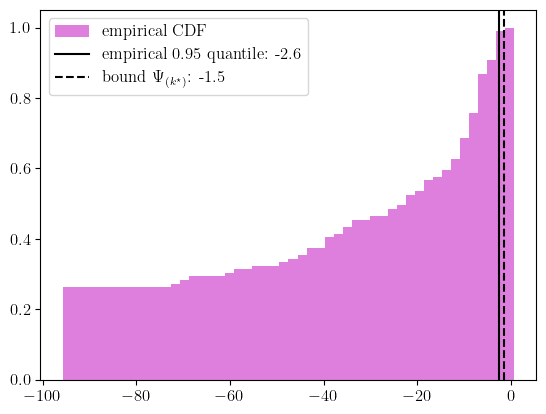

In [79]:
plt.figure()
#plt.title(rf"Empirical CDF of $\Psi$ (L={sequence_lens[s]})")
plt.hist(test_gap[0], bins=50, cumulative=True, density=True, color="m", alpha=0.5, label="empirical CDF");
plt.axvline(test_q[0], color='k', linestyle='-', label=rf"empirical $0.95$ quantile: {test_q[0]:.1f}")
plt.axvline(bound[0], color='k', linestyle='--', label=rf"bound $\Psi_{{(k^\star)}}$: {bound[0]:.1f}")
plt.legend();

In [80]:
tex_fonts = {
    
    # Use LaTeX to write all text
   "text.usetex": True,
   "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
   "axes.labelsize": 16,
   "font.size": 16,

   "legend.fontsize": 14,
   "xtick.labelsize": 14,
   "ytick.labelsize": 14
}

plt.rcParams.update(tex_fonts) # use latex fonts

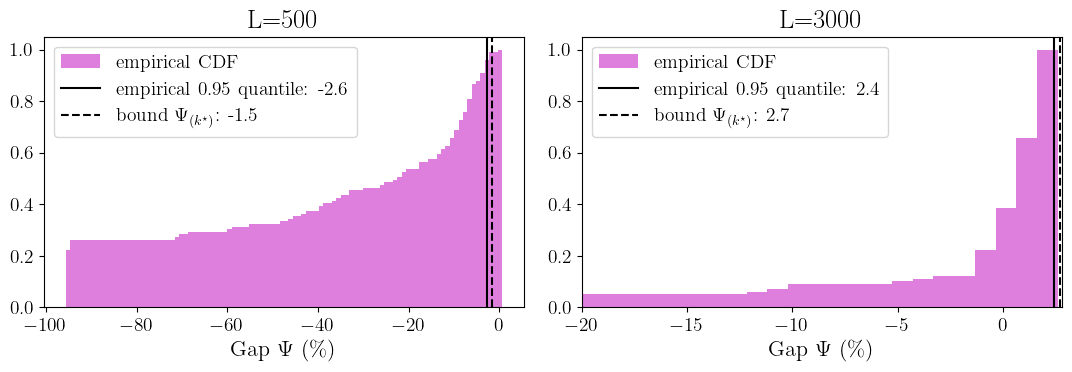

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].set_title(rf"L={sequence_lens[0]}")
ax[0].hist(test_gap[0], bins=100, cumulative=True, density=True, color="m", alpha=0.5, label="empirical CDF");
ax[0].axvline(test_q[0], color='k', linestyle='-', label=rf"empirical $0.95$ quantile: {test_q[0]:.1f}")
ax[0].axvline(bound[0], color='k', linestyle='--', label=rf"bound $\Psi_{{(k^\star)}}$: {bound[0]:.1f}")
ax[0].set_xlabel(r"Gap ${\Psi}$ (\%)")
ax[0].legend();
#ax[0].set_xlim([-100, 30])

ax[1].set_title(rf"L={sequence_lens[1]}")
ax[1].hist(test_gap[1], bins=100, cumulative=True, density=True, color="m", alpha=0.5, label="empirical CDF");
ax[1].axvline(test_q[1], color='k', linestyle='-', label=rf"empirical $0.95$ quantile: {test_q[1]:.1f}")
ax[1].axvline(bound[1], color='k', linestyle='--', label=rf"bound $\Psi_{{(k^\star)}}$: {bound[1]:.1f}")
ax[1].legend();
ax[1].set_xlim([-20, np.maximum(test_gap[1].max(), bound[1])+0.1])
ax[1].set_xlabel(r"Gap ${\Psi}$ (\%)")
plt.tight_layout()
plt.savefig(fig_dir / "bound_vs_empirical_cdf.pdf")